# SymPyによる確率統計の記号的

## 概要

本記事では、Pythonの数式処理ライブラリである **SymPy** を活用し、確率統計における主要な定理や推定法の導出過程を計算機上で再現する手法について解説する。

具体的には、以下の2つのトピックを取り扱う。

1.  **二項分布からポアソン分布への収束**：
    離散分布における極限操作を記号計算によって実行し、ポアソン分布の確率質量関数が導かれる過程を示す。
2.  **正規分布の最尤推定とフィッシャー情報量**：
    連続分布に対する最尤推定において、対数尤度関数の偏微分、ヘッセ行列による極値判定、およびフィッシャー情報行列の導出を行う。

### 筆者の環境
本記事のコードは以下の環境で動作を確認している。


In [1]:
!sw_vers
!python -V

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74
Python 3.12.12



### ライブラリのインポートと設定

必要なライブラリをインポートする。SymPyの数式出力を確認しやすくするため、LaTeX形式での表示を有効化する。


In [2]:
import sympy
from sympy import (
    symbols, Symbol, S, oo, Sum, limit, exp, log, sqrt, pi,
    simplify, binomial, factorial, diff, solve, Eq, Matrix,
    hessian, Function, init_printing, latex, gamma
)
from sympy.stats import Normal, Binomial, density, E, variance
import matplotlib.pyplot as plt
import numpy as np
import math
from IPython.display import display # 数式表示用

# 数式をLaTeX形式で表示するための設定
init_printing()

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

print("sympy version :", sympy.__version__)


sympy version : 1.14.0



## 1. 二項分布からポアソン分布への極限

ポアソン分布は、二項分布において試行回数 $n$ を無限大、成功確率 $p$ を極小とする極限として定義される。ここでは、SymPyを用いてこの極限操作を実行し、ポアソン分布の確率質量関数（PMF）を導出する。

### 1.1 定義

確率変数 $X$ が試行回数 $n$、成功確率 $p$ の二項分布に従うとする。
$$ X \sim B(n, p) $$

このとき、PMFは以下で与えられる。
$$ P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} $$

ここで、以下の条件のもとで極限をとる。
1.  $n \to \infty$
2.  $p \to 0$
3.  $np = \lambda$ (一定)

すなわち、$p = \frac{\lambda}{n}$ とする。


二項分布の確率質量関数 (PMF):


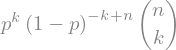

In [3]:
# シンボルの定義
n = symbols('n', integer=True, positive=True)
k = symbols('k', integer=True, nonnegative=True)
p = symbols('p', real=True, positive=True)
lam = symbols('lambda', real=True, positive=True)

# 二項分布のPMF
pmf_binom = binomial(n, k) * p**k * (1 - p)**(n - k)

print("二項分布の確率質量関数 (PMF):")
display(pmf_binom)



### 1.2 項の分解

確率 $p$ を $\lambda / n$ に置換し、$n \to \infty$ の極限を求める。
単純な `limit` 関数の適用では、SymPyの内部アルゴリズムがシンボル $k$ の性質を特定しきれず、計算が完了しない場合がある（`NotImplementedError`）。そこで、数式を収束性質の異なる項に分解し、個別に解析を行うアプローチをとる。

$$ P(X=k) = \underbrace{\frac{n(n-1)\cdots(n-k+1)}{n^k}}_{(A)} \cdot \underbrace{\frac{\lambda^k}{k!}}_{(B)} \cdot \underbrace{\left(1 - \frac{\lambda}{n}\right)^n}_{(C)} \cdot \underbrace{\left(1 - \frac{\lambda}{n}\right)^{-k}}_{(D)} $$

-   **(A)**: $k$ 個の $n$ の一次式の積を $n^k$ で割ったもの。極限値は 1 となるはずである。
-   **(B)**: $n$ に依存しない定数項。
-   **(C)**: ネイピア数 $e$ の定義に関連する項。極限値は $e^{-\lambda}$。
-   **(D)**: 極限値は 1。


分解した項:
Term A:


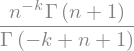

Term C:


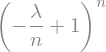

In [4]:
# p -> lambda/n の置換
pmf_sub = pmf_binom.subs(p, lam / n)

# 項の分解
# Term A: nCk * k! / n^k
# binomial(n, k) = gamma(n+1) / (gamma(k+1) * gamma(n-k+1))
term_A = (gamma(n + 1) / gamma(n - k + 1)) / n**k

# Term B: lambda^k / k!
term_B = lam**k / factorial(k)

# Term C: (1 - lambda/n)^n
term_C = (1 - lam / n)**n

# Term D: (1 - lambda/n)^(-k)
term_D = (1 - lam / n)**(-k)

print("分解した項:")
print("Term A:")
display(term_A)
print("Term C:")
display(term_C)



### 1.3 極限計算

各項の極限を求める。
**(A)項について**：
一般の $k$ に対してシンボリックに計算させるとエラーになる場合があるため、ここでは有限の整数 $k=0, 1, 2, 5$ を代入し、すべての場合で極限値が 1 になることを確認する（帰納的な確認）。


In [5]:
# Term A の極限確認 (kを具体的な値にして確認)
print("Term A の極限値確認:")
for k_val in [0, 1, 2, 5]:
    term_A_concrete = term_A.subs(k, k_val)
    lim_val = limit(term_A_concrete, n, oo)
    print(f"k={k_val}: limit = {lim_val}")

# 従って、一般の有限整数kにおいて Term A -> 1 とみなす
lim_A = 1


Term A の極限値確認:
k=0: limit = 1
k=1: limit = 1
k=2: limit = 1
k=5: limit = 1



**(C)項、(D)項について**：
これらは標準的な極限計算として求まる。


In [6]:
# Term C, D の極限
lim_C = limit(term_C, n, oo)
lim_D = limit(term_D, n, oo)

print("Term C の極限:", lim_C)
print("Term D の極限:", lim_D)


Term C の極限: exp(-lambda)
Term D の極限: 1



### 1.4 結果の結合

以上の結果を結合し、ポアソン分布の式が再構成されることを確認する。

$$ 1 \cdot \frac{\lambda^k}{k!} \cdot e^{-\lambda} \cdot 1 = \frac{\lambda^k e^{-\lambda}}{k!} $$


導出されたポアソン分布:


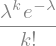

数式の一致確認: True


In [7]:
# 全体の計算結果
poisson_pmf_derived = lim_A * term_B * lim_C * lim_D

print("導出されたポアソン分布:")
display(poisson_pmf_derived)

# 理論式との比較
expected_poisson_pmf = (lam**k * exp(-lam)) / factorial(k)
print("数式の一致確認:", simplify(poisson_pmf_derived - expected_poisson_pmf) == 0)



### 1.5 収束の可視化

$n$ の値を増加させた際の分布形状の変化を可視化する。パラメーターは $\lambda=5$ とする。


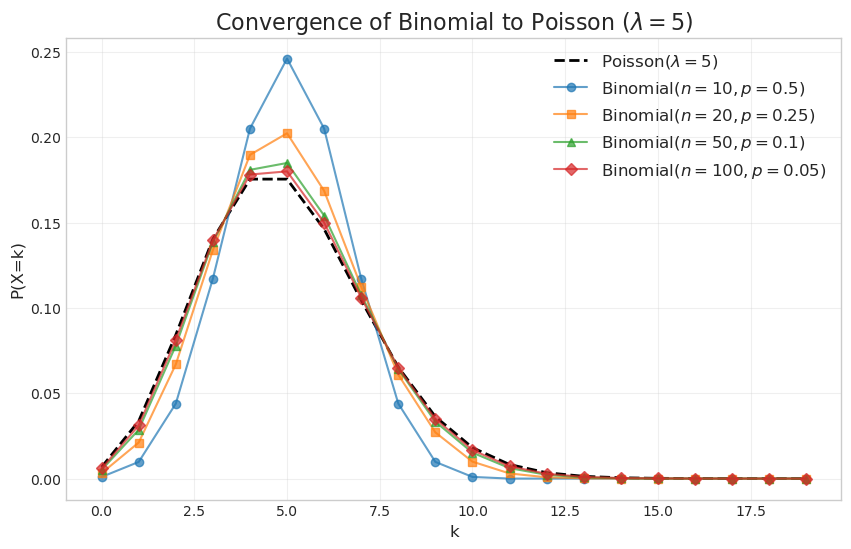

In [8]:
def plot_convergence(lam_val=5, n_list=[10, 20, 50, 100]):
    k_vals = np.arange(0, 20)

    plt.figure(figsize=(10, 6))

    # ポアソン分布（理論値）
    # np.math は非推奨のため math を使用
    poisson_probs = [np.exp(-lam_val) * (lam_val**k_i) / math.factorial(k_i) for k_i in k_vals]
    plt.plot(k_vals, poisson_probs, 'k--', linewidth=2, label=rf'Poisson($\lambda={lam_val}$)')

    # 二項分布
    markers = ['o', 's', '^', 'D']
    for i, n_val in enumerate(n_list):
        p_val = lam_val / n_val
        binom_probs = []
        for k_i in k_vals:
            if k_i > n_val:
                prob = 0
            else:
                coef = math.comb(n_val, k_i)
                prob = coef * (p_val**k_i) * ((1 - p_val)**(n_val - k_i))
            binom_probs.append(prob)

        plt.plot(k_vals, binom_probs, marker=markers[i % len(markers)], linestyle='-', alpha=0.7, label=f'Binomial($n={n_val}, p={p_val:.3g}$)')

    plt.title(rf'Convergence of Binomial to Poisson ($\lambda={lam_val}$)', fontsize=16)
    plt.xlabel('k', fontsize=12)
    plt.ylabel('P(X=k)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_convergence(lam_val=5)



$n$ の増加に伴い、二項分布がポアソン分布へ収束することが確認できる。

---

## 2. 正規分布の最尤推定とフィッシャー情報量

続いて、正規分布に対する最尤推定を行う。対数尤度関数の最大化条件から推定量（MLE）を求め、さらにヘッセ行列を用いて極大性を確認する。また、フィッシャー情報行列を計算する。

### 2.1 尤度関数の設定

$n$ 個の独立なデータ $\mathcal{D} = \{x_1, \dots, x_n\}$ が正規分布 $\mathcal{N}(\mu, \sigma^2)$ に従うとする。
確率密度関数（PDF）は以下である。

$$ f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) $$


正規分布のPDF:


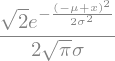

In [9]:
# シンボルの定義
mu = symbols('mu', real=True)
sigma = symbols('sigma', real=True, positive=True)
x = symbols('x', real=True)
n_samples = symbols('n', integer=True, positive=True)

# 正規分布のPDF
pdf_normal = 1 / sqrt(2 * pi * sigma**2) * exp(-(x - mu)**2 / (2 * sigma**2))

print("正規分布のPDF:")
display(pdf_normal)



### 2.2 対数尤度関数の定義

対数尤度関数 $\ell(\mu, \sigma) = \sum \ln f(x_i)$ を定義する。
計算の便宜上、総和項を $s_1 = \sum x_i$ および $s_2 = \sum x_i^2$ を用いて表す。

$$ \ell(\mu, \sigma) = -\frac{n}{2}\ln(2\pi) - n\ln(\sigma) - \frac{1}{2\sigma^2} (s_2 - 2\mu s_1 + n\mu^2) $$


対数尤度関数:


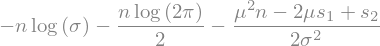

In [10]:
# 定数項と対数項
term1 = -n_samples / 2 * log(2 * pi)
term2 = -n_samples * log(sigma)

# 二乗和の展開項
s_1 = symbols('s_1', real=True) # sum(x_i)
s_2 = symbols('s_2', real=True) # sum(x_i^2)
sum_sq_expanded = s_2 - 2*mu*s_1 + n_samples * mu**2

# 対数尤度関数
log_L_calc = term1 + term2 - 1/(2*sigma**2) * sum_sq_expanded

print("対数尤度関数:")
display(log_L_calc)



### 2.3 最尤推定量の導出

パラメータ $\mu, \sigma$ について偏微分し、0とおくことでMLEを求める。

#### $\mu$ の推定
$$ \frac{\partial \ell}{\partial \mu} = 0 $$


スコア関数 (mu):


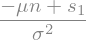

mu の最尤推定量:


In [11]:
# mu で偏微分
d_logL_d_mu = diff(log_L_calc, mu)

print("スコア関数 (mu):")
display(simplify(d_logL_d_mu))

# 方程式の解
mu_solution = solve(Eq(d_logL_d_mu, 0), mu)

print("mu の最尤推定量:")
display(mu_solution[0])



結果は標本平均 $\bar{x} = s_1/n$ である。

#### $\sigma$ の推定
$$ \frac{\partial \ell}{\partial \sigma} = 0 $$


スコア関数 (sigma):


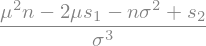

sigma の最尤推定量:


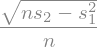

In [12]:
# sigma で偏微分
d_logL_d_sigma = diff(log_L_calc, sigma)

print("スコア関数 (sigma):")
display(simplify(d_logL_d_sigma))

# mu に解を代入して解く
d_logL_d_sigma_subs = d_logL_d_sigma.subs(mu, mu_solution[0])
sigma_solutions = solve(Eq(d_logL_d_sigma_subs, 0), sigma)

# 正の解を選択
sigma_mle = [s for s in sigma_solutions if not s.is_negative][0]

print("sigma の最尤推定量:")
display(sigma_mle)



結果は標本標準偏差である。

### 2.4 ヘッセ行列による検証

ヘッセ行列 $H$ を計算し、その負定値性を確認する。
$$ H = \begin{pmatrix} \frac{\partial^2 \ell}{\partial \mu^2} & \frac{\partial^2 \ell}{\partial \mu \partial \sigma} \\ \frac{\partial^2 \ell}{\partial \sigma \partial \mu} & \frac{\partial^2 \ell}{\partial \sigma^2} \end{pmatrix} $$


ヘッセ行列:


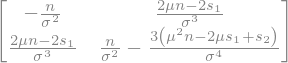

(1,1)成分の値:


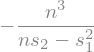

In [13]:
# ヘッセ行列の計算
vars_list = [mu, sigma]
hessian_mat = hessian(log_L_calc, vars_list)

print("ヘッセ行列:")
display(hessian_mat)

# 推定値における評価 (1,1)成分
H_at_mle = hessian_mat.subs({
    mu: mu_solution[0],
    sigma: sigma_mle
})

h11_val = simplify(H_at_mle[0, 0])
print("(1,1)成分の値:")
display(h11_val)



$(1,1)$ 成分は $-n/\sigma^2$ (負) となる。行列式も正となるため、この点は極大点である。

### 2.5 フィッシャー情報行列

フィッシャー情報行列 $I(\theta) = -E[H(\theta)]$ を計算する。


フィッシャー情報行列:


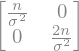

In [14]:
# 期待値計算
# E[x_i] = mu, E[(x_i-mu)^2] = sigma^2
i11 = -hessian_mat[0, 0]
i12 = 0
term_sum_sq = n_samples * sigma**2
val_h22 = hessian_mat[1, 1].subs(sum_sq_expanded, term_sum_sq)
i22 = -(-2 * n_samples / sigma**2)

Fisher_Info = Matrix([
    [i11, i12],
    [i12, i22]
])

print("フィッシャー情報行列:")
display(Fisher_Info)



対角行列が得られ、パラメータ間の直交性が確認された。

### 2.6 対数尤度の等高線プロット

対数尤度関数の形状を可視化する。


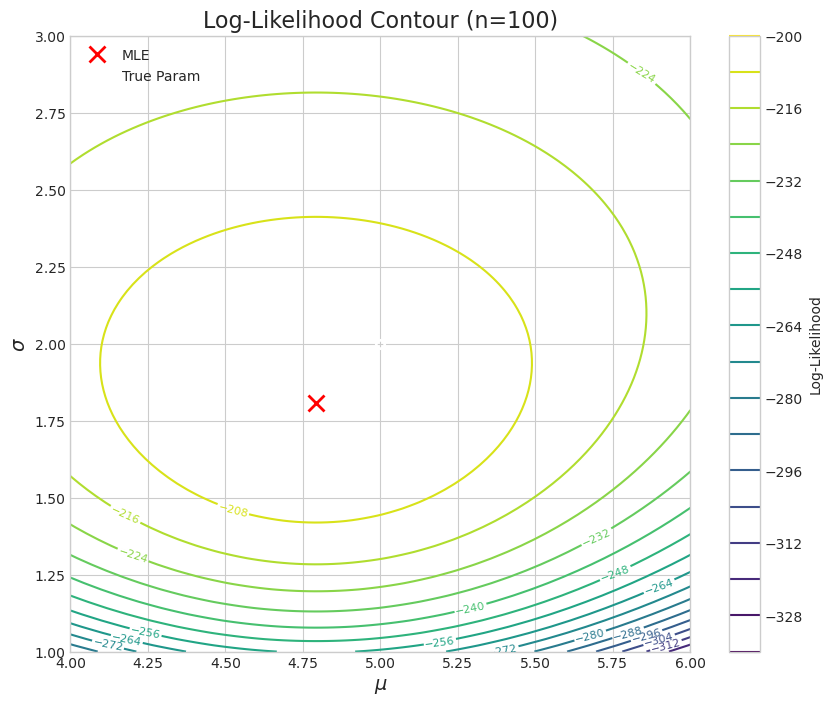

In [15]:
def plot_log_likelihood(n=100, true_mu=5.0, true_sigma=2.0):
    np.random.seed(42)
    data = np.random.normal(true_mu, true_sigma, n)

    sample_mean = np.mean(data)
    sample_std = np.std(data)

    mu_range = np.linspace(true_mu - 1.0, true_mu + 1.0, 100)
    sigma_range = np.linspace(true_sigma - 1.0, true_sigma + 1.0, 100)
    MU, SIGMA = np.meshgrid(mu_range, sigma_range)

    term1 = -n/2 * np.log(2 * np.pi)
    term2 = -n * np.log(SIGMA)
    SSD = np.sum((data[:, np.newaxis, np.newaxis] - MU)**2, axis=0)
    LOG_L = term1 + term2 - SSD / (2 * SIGMA**2)

    plt.figure(figsize=(10, 8))
    contours = plt.contour(MU, SIGMA, LOG_L, levels=20, cmap='viridis')
    plt.clabel(contours, inline=True, fontsize=8)

    plt.plot(sample_mean, sample_std, 'rx', markersize=12, markeredgewidth=2, label='MLE')
    plt.plot(true_mu, true_sigma, 'wo', markerfacecolor='none', markeredgewidth=2, label='True Param')

    plt.title(rf'Log-Likelihood Contour (n={n})', fontsize=16)
    plt.xlabel(rf'$\mu$', fontsize=14)
    plt.ylabel(rf'$\sigma$', fontsize=14)
    plt.legend()
    plt.colorbar(label='Log-Likelihood')
    plt.show()

plot_log_likelihood()



## 結論

この記事では、SymPyを用いた統計モデルの数理解析を行った。

1.  **極限操作の記号化**：二項分布からポアソン分布への収束を、項分解と数値確認を用いた安全な手法で導出し、SymPyの計算能力を示した。
2.  **最尤推定の自動化**：正規分布を例に、尤度関数の微分からヘッセ行列、フィッシャー情報量の導出までを一貫して行った。